<a href="https://colab.research.google.com/github/EL-3raby/Caf-Harmony-Analysis/blob/main/Caf%C3%A9Harmony.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

# 1. Generating Mock Data for 'Café Harmony'
np.random.seed(42)
data_size = 100
dates = [datetime(2024, 1, 1) + timedelta(days=i) for i in range(data_size)]

data = {
    'Date': dates,
    'Marketing_Channel': np.random.choice(['Local_Flyers', 'Instagram_Ads', 'TikTok_Promo', 'Food_Blogger', None], data_size),
    'Ad_Spend': np.random.uniform(20, 150, data_size), # بالدولار
    'Total_Orders': np.random.randint(10, 80, data_size), # عدد الطلبات
    'Revenue': np.random.uniform(100, 800, data_size), # الإيرادات
    'Customer_Rating': np.random.choice([2, 3, 4, 5, np.nan], data_size) # تقييمات من 5
}

df = pd.DataFrame(data)

# Injecting intentional errors for the cleaning process
df.loc[0] = df.loc[1] # Duplicate row
df.loc[5, 'Ad_Spend'] = -30 # Negative spend (Error)
df.loc[10, 'Revenue'] = 15000 # Massive outlier
df.loc[15, 'Marketing_Channel'] = 'Instagram_Ads' # Fixing a None manually just in case

print("✅ Café Harmony Dataset Created with Intentional Errors!")

✅ Café Harmony Dataset Created with Intentional Errors!


In [2]:
# --- A. Data Cleaning ---
print("--- Data Cleaning Process ---")

# 1. Remove duplicates
df_cleaned = df.drop_duplicates().copy()

# 2. Handle Missing Values (Fill missing ratings with median)
median_rating = df_cleaned['Customer_Rating'].median()
df_cleaned['Customer_Rating'] = df_cleaned['Customer_Rating'].fillna(median_rating)

# 3. Handle Missing Channels (Drop rows with None in channel)
df_cleaned = df_cleaned.dropna(subset=['Marketing_Channel'])

# 4. Fix illogical values (Convert negative Ad_Spend to positive)
df_cleaned['Ad_Spend'] = df_cleaned['Ad_Spend'].abs()

# 5. Handle Outliers (Cap Revenue at a realistic maximum, e.g., 2000)
df_cleaned.loc[df_cleaned['Revenue'] > 2000, 'Revenue'] = 2000

print(f"Data cleaned. Remaining rows: {len(df_cleaned)}")

# --- B. Data Processing & Metrics ---
print("\n--- Calculating Business Metrics ---")

# Calculate ROAS (Return on Ad Spend)
df_cleaned['ROAS'] = df_cleaned['Revenue'] / df_cleaned['Ad_Spend']

# Calculate CPA (Cost Per Acquisition / Order)
df_cleaned['CPA'] = df_cleaned['Ad_Spend'] / df_cleaned['Total_Orders']

# Round the results
df_cleaned = df_cleaned.round({'ROAS': 2, 'CPA': 2, 'Ad_Spend': 2, 'Revenue': 2})

print("✅ Metrics Calculated: ROAS & CPA Added!")
display(df_cleaned.head())

--- Data Cleaning Process ---
Data cleaned. Remaining rows: 80

--- Calculating Business Metrics ---
✅ Metrics Calculated: ROAS & CPA Added!


,Date,Marketing_Channel,Ad_Spend,Total_Orders,Revenue,Customer_Rating,ROAS,CPA
2,2024-01-03,TikTok_Promo,78.43,59,393.85,5.0,5.02,1.33
5,2024-01-06,Instagram_Ads,30.00,51,157.12,4.0,5.24,0.59
6,2024-01-07,TikTok_Promo,106.57,16,103.63,3.0,0.97,6.66
7,2024-01-08,TikTok_Promo,96.87,25,539.53,4.0,5.57,3.87
8,2024-01-09,TikTok_Promo,55.71,69,235.99,2.0,4.24,0.81


/tmp/ipykernel_5765/2957633684.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0], data=roas_by_channel, x='Marketing_Channel', y='ROAS', palette='viridis')


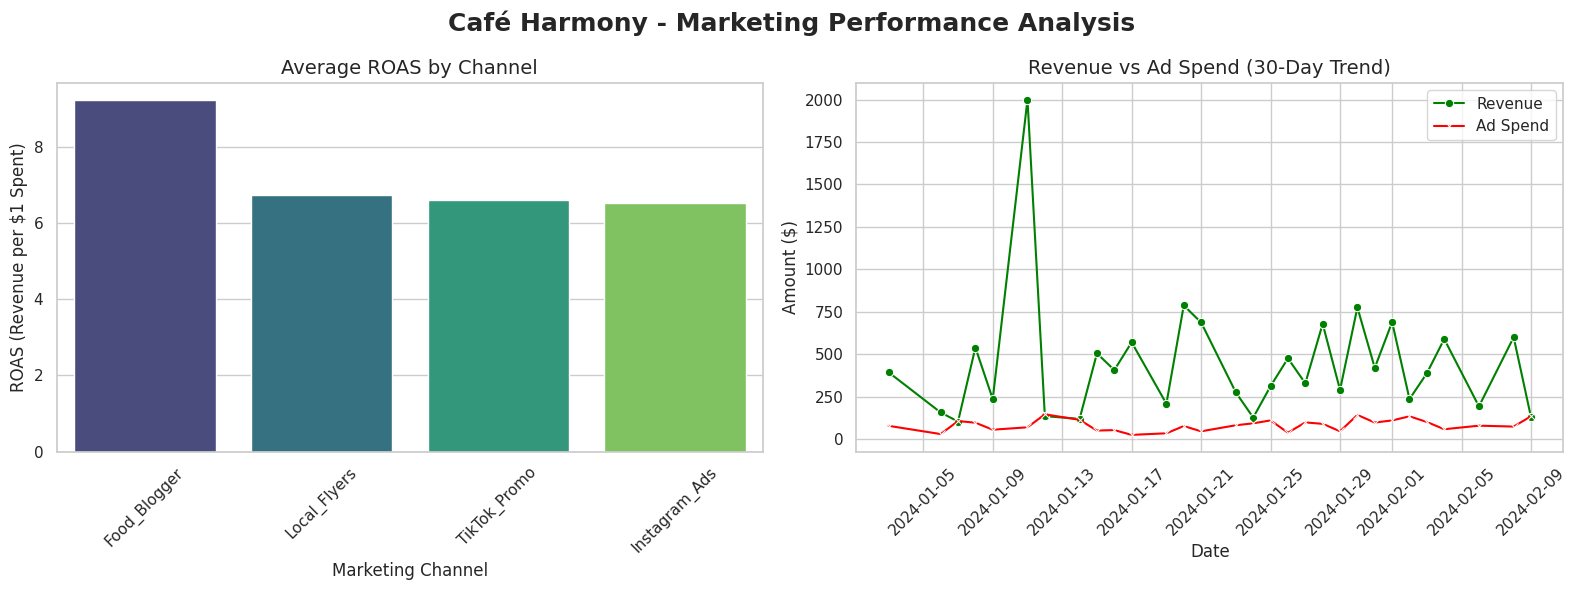


🔥 Top Business Insights for Café Harmony:
1. The most profitable marketing channel is 'Food_Blogger' with an average ROAS of 9.21.
2. The average Cost Per Order (CPA) across all campaigns is $2.06.


In [3]:
# Set the aesthetic style of the plots
sns.set_theme(style="whitegrid")

# Create a figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Café Harmony - Marketing Performance Analysis', fontsize=18, fontweight='bold')

# Plot 1: Average ROAS by Marketing Channel
roas_by_channel = df_cleaned.groupby('Marketing_Channel')['ROAS'].mean().sort_values(ascending=False).reset_index()
sns.barplot(ax=axes[0], data=roas_by_channel, x='Marketing_Channel', y='ROAS', palette='viridis')
axes[0].set_title('Average ROAS by Channel', fontsize=14)
axes[0].set_xlabel('Marketing Channel', fontsize=12)
axes[0].set_ylabel('ROAS (Revenue per $1 Spent)', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

# Plot 2: Total Revenue vs Ad Spend Trend (First 30 days for clarity)
sns.lineplot(ax=axes[1], data=df_cleaned.head(30), x='Date', y='Revenue', label='Revenue', color='green', marker='o')
sns.lineplot(ax=axes[1], data=df_cleaned.head(30), x='Date', y='Ad_Spend', label='Ad Spend', color='red', marker='x')
axes[1].set_title('Revenue vs Ad Spend (30-Day Trend)', fontsize=14)
axes[1].set_xlabel('Date', fontsize=12)
axes[1].set_ylabel('Amount ($)', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()

plt.tight_layout()
plt.show()

# Print Top Business Insights
print("\n🔥 Top Business Insights for Café Harmony:")
best_channel = roas_by_channel.iloc[0]['Marketing_Channel']
best_roas = roas_by_channel.iloc[0]['ROAS']
print(f"1. The most profitable marketing channel is '{best_channel}' with an average ROAS of {best_roas:.2f}.")
avg_cpa = df_cleaned['CPA'].mean()
print(f"2. The average Cost Per Order (CPA) across all campaigns is ${avg_cpa:.2f}.")

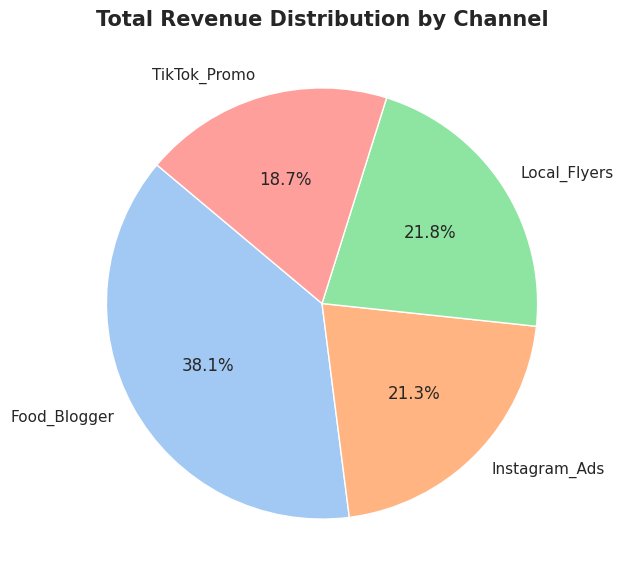

💡 Insight: This chart shows which channel contributes the most to your total income.


In [5]:
# 1. Revenue Share by Channel (Pie Chart)
plt.figure(figsize=(10, 7))
revenue_distribution = df_cleaned.groupby('Marketing_Channel')['Revenue'].sum()
plt.pie(revenue_distribution, labels=revenue_distribution.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Total Revenue Distribution by Channel', fontsize=15, fontweight='bold')
plt.show()

print("💡 Insight: This chart shows which channel contributes the most to your total income.")

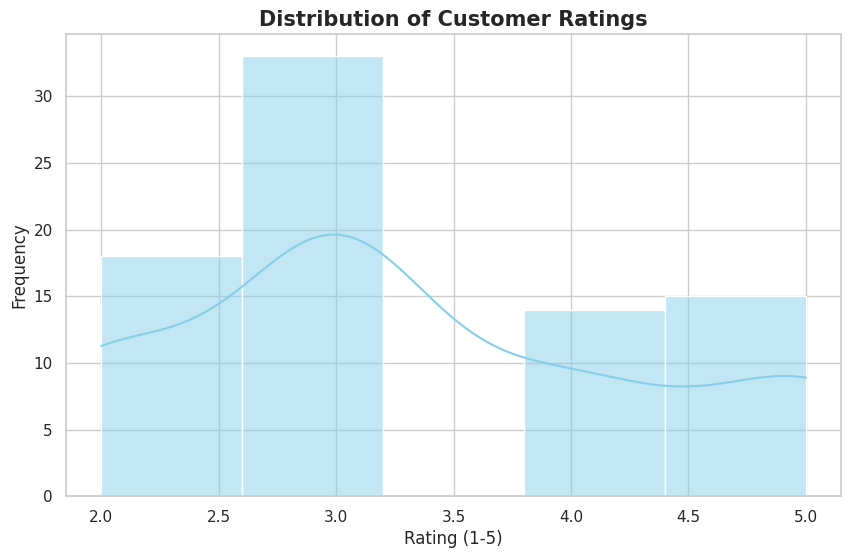

💡 Insight: The average customer rating is 3.33/5.


In [6]:
# 2. Customer Rating Distribution
plt.figure(figsize=(10, 6))
sns.histplot(df_cleaned['Customer_Rating'], bins=5, kde=True, color='skyblue')
plt.title('Distribution of Customer Ratings', fontsize=15, fontweight='bold')
plt.xlabel('Rating (1-5)')
plt.ylabel('Frequency')
plt.show()

print(f"💡 Insight: The average customer rating is {df_cleaned['Customer_Rating'].mean():.2f}/5.")

/tmp/ipykernel_5765/3070140956.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=aov_by_channel, x='Marketing_Channel', y='AOV', palette='magma')


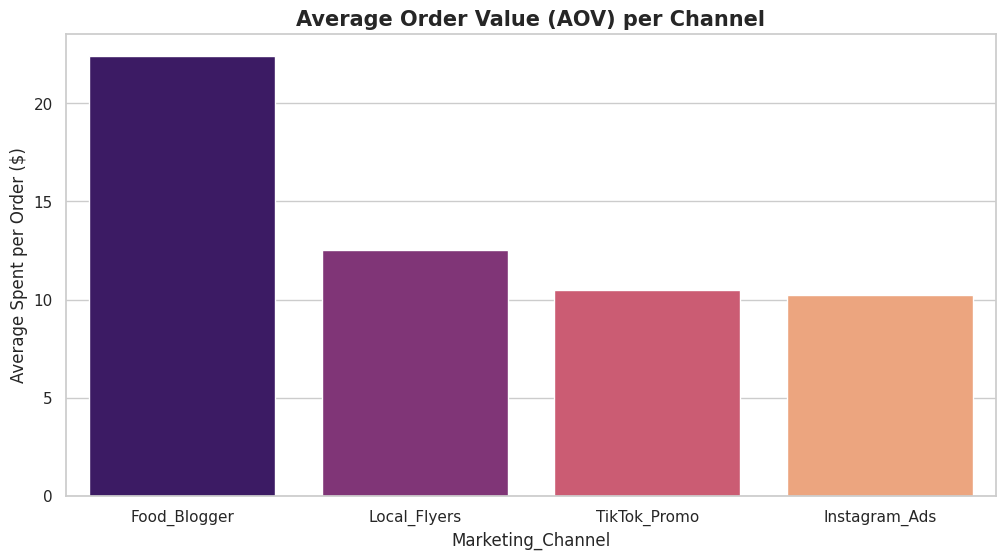

💡 Insight: High AOV indicates that customers from this channel tend to buy more expensive items.


In [8]:
# 3. Average Order Value (AOV) by Channel
plt.figure(figsize=(12, 6))
df_cleaned['AOV'] = df_cleaned['Revenue'] / df_cleaned['Total_Orders']
aov_by_channel = df_cleaned.groupby('Marketing_Channel')['AOV'].mean().sort_values(ascending=False).reset_index()

sns.barplot(data=aov_by_channel, x='Marketing_Channel', y='AOV', palette='magma')
plt.title('Average Order Value (AOV) per Channel', fontsize=15, fontweight='bold')
plt.ylabel('Average Spent per Order ($)')
plt.show()

print("💡 Insight: High AOV indicates that customers from this channel tend to buy more expensive items.")

In [4]:
# حفظ البيانات المتنظفة في ملف إكسيل
file_name = 'Cafe_Harmony_Cleaned_Data.xlsx'
df_cleaned.to_excel(file_name, index=False)

print(f"✅ تم حفظ التقرير بنجاح باسم: {file_name}")
print("تقدر تحمله دلوقتي من قائمة الملفات (Files) على الشمال في كولاب!")

✅ تم حفظ التقرير بنجاح باسم: Cafe_Harmony_Cleaned_Data.xlsx
تقدر تحمله دلوقتي من قائمة الملفات (Files) على الشمال في كولاب!
